# Analise de Prejuizo por Produto - Questao 4

## Objetivo
Identificar vendas em que os produtos foram vendidos abaixo do custo de importacao, considerando a taxa de cambio diaria USD/BRL (cotacao PTAX do Banco Central).

## Premissas
- Custo USD e unitario (por produto)
- Custo total em BRL = usd_price * taxa_cambio * qtd
- Taxa de cambio = media da cotacao de venda (PTAX) do dia da transacao
- Para dias sem cotacao (fins de semana e feriados), utiliza-se a cotacao do ultimo dia util anterior (forward fill)
- Receita considera todas as vendas (incluindo as lucrativas)
- Impostos e frete nao sao considerados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Carregamento dos Dados

In [2]:
df_vendas = pd.read_csv('../datasets/vendas_2023_2024.csv')

with open('../datasets/custos_importacao.json', 'r', encoding='utf-8') as f:
    custos_raw = json.load(f)

print(f"Vendas carregadas: {df_vendas.shape[0]} registros")
print(f"Produtos com custo: {len(custos_raw)} produtos")
df_vendas.head()

Vendas carregadas: 9895 registros
Produtos com custo: 150 produtos


,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,3405.0,2023-09-10
1,1,3,136,9,16873.9,15-09-2024
2,2,25,139,7,9475.3,2024-08-13
3,4,20,23,5,55893.0,2023-02-03
4,5,8,57,4,451403.9,2024-02-12


## 2. Tratamento de Datas

In [3]:
df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'], format='mixed', dayfirst=True)

print(f"Periodo das vendas: {df_vendas['sale_date'].min().strftime('%d/%m/%Y')} a {df_vendas['sale_date'].max().strftime('%d/%m/%Y')}")
print(f"Registros apos conversao: {df_vendas['sale_date'].notna().sum()}")

Periodo das vendas: 01/01/2023 a 31/12/2024
Registros apos conversao: 9895


## 3. Preparacao dos Custos de Importacao

Transformar a estrutura aninhada do JSON em um DataFrame plano, com uma linha por entrada historica de custo.

In [4]:
registros_custo = []
for produto in custos_raw:
    pid = produto['product_id']
    for entrada in produto['historic_data']:
        registros_custo.append({
            'product_id': pid,
            'start_date': entrada['start_date'],
            'usd_price': entrada['usd_price']
        })

df_custos = pd.DataFrame(registros_custo)
df_custos['start_date'] = pd.to_datetime(df_custos['start_date'], format='%d/%m/%Y')
df_custos = df_custos.sort_values(['product_id', 'start_date']).reset_index(drop=True)

print(f"Registros de custo: {len(df_custos)}")
print(f"Produtos distintos: {df_custos['product_id'].nunique()}")
df_custos.head(10)

Registros de custo: 1260
Produtos distintos: 150


,product_id,start_date,usd_price
0,1,2016-08-10,10583.63
1,1,2018-06-15,8778.36
2,1,2018-09-25,8023.87
3,1,2019-03-19,8772.78
4,1,2020-01-17,7918.18
5,1,2020-06-17,6310.01
6,1,2021-07-02,6586.70
7,1,2022-05-16,6538.20
8,1,2023-02-28,6360.91
9,1,2023-10-17,6574.80


## 4. Obtencao da Taxa de Cambio (PTAX - Banco Central)

Consulta a API do Banco Central para obter a cotacao de venda do dolar para o periodo de 2023-2024.

In [5]:
url_bcb = (
    "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
    "CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)"
    "?@dataInicial='01-01-2023'"
    "&@dataFinalCotacao='12-31-2024'"
    "&$top=10000"
    "&$format=json"
    "&$select=cotacaoVenda,dataHoraCotacao"
)

try:
    response = requests.get(url_bcb, timeout=30)
    response.raise_for_status()
    dados_cambio = response.json()['value']
    print(f"Cotacoes obtidas da API: {len(dados_cambio)} registros")
except requests.exceptions.RequestException as e:
    raise ConnectionError(
        f"Falha ao acessar a API do Banco Central: {e}\n"
        "Verifique sua conexao com a internet e tente novamente."
    )

Cotacoes obtidas da API: 502 registros


In [6]:
df_cambio = pd.DataFrame(dados_cambio)
df_cambio['data'] = pd.to_datetime(df_cambio['dataHoraCotacao']).dt.date
df_cambio['data'] = pd.to_datetime(df_cambio['data'])

df_cambio_diario = (
    df_cambio
    .groupby('data')['cotacaoVenda']
    .mean()
    .reset_index()
    .rename(columns={'cotacaoVenda': 'taxa_cambio'})
)

print(f"Dias uteis com cotacao: {len(df_cambio_diario)}")
print(f"Periodo: {df_cambio_diario['data'].min().strftime('%d/%m/%Y')} a {df_cambio_diario['data'].max().strftime('%d/%m/%Y')}")
df_cambio_diario.head()

Dias uteis com cotacao: 502
Periodo: 02/01/2023 a 31/12/2024


,data,taxa_cambio
0,2023-01-02,5.3436
1,2023-01-03,5.3759
2,2023-01-04,5.4459
3,2023-01-05,5.4026
4,2023-01-06,5.2855


In [7]:
datas_completas = pd.date_range(
    start='2023-01-01',
    end='2024-12-31',
    freq='D'
)

df_cambio_completo = (
    pd.DataFrame({'data': datas_completas})
    .merge(df_cambio_diario, on='data', how='left')
)

df_cambio_completo['taxa_cambio'] = df_cambio_completo['taxa_cambio'].ffill()

dias_preenchidos = df_cambio_completo['taxa_cambio'].notna().sum()
print(f"Total de dias no periodo: {len(df_cambio_completo)}")
print(f"Dias com taxa (apos forward fill): {dias_preenchidos}")
print(f"\nEstatisticas da taxa de cambio:")
print(df_cambio_completo['taxa_cambio'].describe())

Total de dias no periodo: 731
Dias com taxa (apos forward fill): 730

Estatisticas da taxa de cambio:
count    730.000000
mean       5.192964
std        0.340560
min        4.720200
25%        4.939700
50%        5.068300
75%        5.442725
max        6.199100
Name: taxa_cambio, dtype: float64


In [8]:
df_cambio_completo.to_csv('../outputs/dados_processados/cambio_diario.csv', index=False)
print("Dados de cambio salvos em: ../outputs/dados_processados/cambio_diario.csv")

Dados de cambio salvos em: ../outputs/dados_processados/cambio_diario.csv


## 5. Associacao de Custos as Vendas (merge_asof)

Para cada venda, encontrar o custo vigente na data da transacao, ou seja, a entrada de custo mais recente com `start_date <= sale_date`.

In [9]:
df_vendas_sorted = df_vendas.sort_values('sale_date').reset_index(drop=True)
df_custos_sorted = df_custos.sort_values('start_date').reset_index(drop=True)

df_vendas_sorted = df_vendas_sorted.rename(columns={'id_product': 'product_id'})

df_merged = pd.merge_asof(
    df_vendas_sorted,
    df_custos_sorted,
    left_on='sale_date',
    right_on='start_date',
    by='product_id',
    direction='backward'
)

print(f"Vendas com custo associado: {df_merged['usd_price'].notna().sum()} de {len(df_merged)}")
print(f"Vendas sem custo associado: {df_merged['usd_price'].isna().sum()}")
df_merged[['id', 'product_id', 'sale_date', 'start_date', 'usd_price', 'total', 'qtd']].head(10)

Vendas com custo associado: 9895 de 9895
Vendas sem custo associado: 0


,id,product_id,sale_date,start_date,usd_price,total,qtd
0,1230,91,2023-01-01,2022-03-16,26303.31,512566.80,4
1,2300,95,2023-01-01,2022-11-23,12945.63,596858.40,9
2,3131,130,2023-01-01,2021-03-22,749.89,53873.00,13
3,4212,96,2023-01-01,2022-09-30,13063.42,402538.75,6
4,4294,44,2023-01-01,2022-01-17,1963.02,51332.30,5
5,4997,133,2023-01-01,2022-07-06,348.47,1893.00,1
6,3549,53,2023-01-01,2022-07-19,9958.63,662886.25,13
7,5256,78,2023-01-01,2022-10-14,23053.04,1461139.00,12
8,666,15,2023-01-01,2022-12-06,5325.40,132524.05,5
9,7765,22,2023-01-01,2022-08-22,7630.67,74960.70,2


## 6. Associacao da Taxa de Cambio

In [10]:
df_merged['data_venda'] = df_merged['sale_date'].dt.normalize()
df_cambio_completo['data'] = pd.to_datetime(df_cambio_completo['data'])

df_analise = df_merged.merge(
    df_cambio_completo,
    left_on='data_venda',
    right_on='data',
    how='left'
)

print(f"Registros com taxa de cambio: {df_analise['taxa_cambio'].notna().sum()} de {len(df_analise)}")
df_analise[['id', 'product_id', 'sale_date', 'usd_price', 'taxa_cambio', 'qtd', 'total']].head(10)

Registros com taxa de cambio: 9884 de 9895


,id,product_id,sale_date,usd_price,taxa_cambio,qtd,total
0,1230,91,2023-01-01,26303.31,NaN,4,512566.80
1,2300,95,2023-01-01,12945.63,NaN,9,596858.40
2,3131,130,2023-01-01,749.89,NaN,13,53873.00
3,4212,96,2023-01-01,13063.42,NaN,6,402538.75
4,4294,44,2023-01-01,1963.02,NaN,5,51332.30
5,4997,133,2023-01-01,348.47,NaN,1,1893.00
6,3549,53,2023-01-01,9958.63,NaN,13,662886.25
7,5256,78,2023-01-01,23053.04,NaN,12,1461139.00
8,666,15,2023-01-01,5325.40,NaN,5,132524.05
9,7765,22,2023-01-01,7630.67,NaN,2,74960.70


## 7. Calculo de Custo e Identificacao de Prejuizo

In [11]:
df_analise['custo_total_brl'] = (
    df_analise['usd_price'] * df_analise['taxa_cambio'] * df_analise['qtd']
)

df_analise['prejuizo'] = np.where(
    df_analise['custo_total_brl'] > df_analise['total'],
    df_analise['custo_total_brl'] - df_analise['total'],
    0.0
)

total_vendas_com_prejuizo = (df_analise['prejuizo'] > 0).sum()
total_vendas_sem_prejuizo = (df_analise['prejuizo'] == 0).sum()

print(f"Vendas com prejuizo: {total_vendas_com_prejuizo}")
print(f"Vendas sem prejuizo: {total_vendas_sem_prejuizo}")
print(f"Prejuizo total: R$ {df_analise['prejuizo'].sum():,.2f}")

df_analise[['id', 'product_id', 'total', 'custo_total_brl', 'prejuizo']].head(10)

Vendas com prejuizo: 6172
Vendas sem prejuizo: 3723
Prejuizo total: R$ 182,144,538.88


,id,product_id,total,custo_total_brl,prejuizo
0,1230,91,512566.80,NaN,0.0
1,2300,95,596858.40,NaN,0.0
2,3131,130,53873.00,NaN,0.0
3,4212,96,402538.75,NaN,0.0
4,4294,44,51332.30,NaN,0.0
5,4997,133,1893.00,NaN,0.0
6,3549,53,662886.25,NaN,0.0
7,5256,78,1461139.00,NaN,0.0
8,666,15,132524.05,NaN,0.0
9,7765,22,74960.70,NaN,0.0


## 8. Agregacao por Produto

In [12]:
df_produto = (
    df_analise
    .groupby('product_id')
    .agg(
        receita_total=('total', 'sum'),
        prejuizo_total=('prejuizo', 'sum'),
        qtd_vendas=('id', 'count'),
        vendas_com_prejuizo=('prejuizo', lambda x: (x > 0).sum())
    )
    .reset_index()
)

df_produto['percentual_perda'] = (
    df_produto['prejuizo_total'] / df_produto['receita_total'] * 100
).round(2)

df_produto = df_produto.sort_values('prejuizo_total', ascending=False).reset_index(drop=True)

print("Produtos com prejuizo (ordenados por prejuizo total):")
df_com_prejuizo = df_produto[df_produto['prejuizo_total'] > 0].copy()
print(f"Total de produtos com prejuizo: {len(df_com_prejuizo)}")
df_com_prejuizo.head(15)

Produtos com prejuizo (ordenados por prejuizo total):
Total de produtos com prejuizo: 150


,product_id,receita_total,prejuizo_total,qtd_vendas,vendas_com_prejuizo,percentual_perda
0,72,63057815.65,3.982104e+07,78,78,63.15
1,83,44377440.00,1.861429e+07,44,44,41.95
2,74,59764356.15,6.716610e+06,85,63,11.24
3,71,81567066.65,6.070816e+06,78,66,7.44
4,55,61224375.00,5.371141e+06,74,73,8.77
5,63,68817185.90,4.848430e+06,65,52,7.05
6,91,66829268.70,4.847516e+06,63,53,7.25
7,78,58043733.35,4.171485e+06,61,49,7.19
8,60,53418532.00,3.183628e+06,63,43,5.96
9,73,69554254.80,2.988374e+06,68,43,4.30


## 9. Visualizacao - Prejuizo Total por Produto

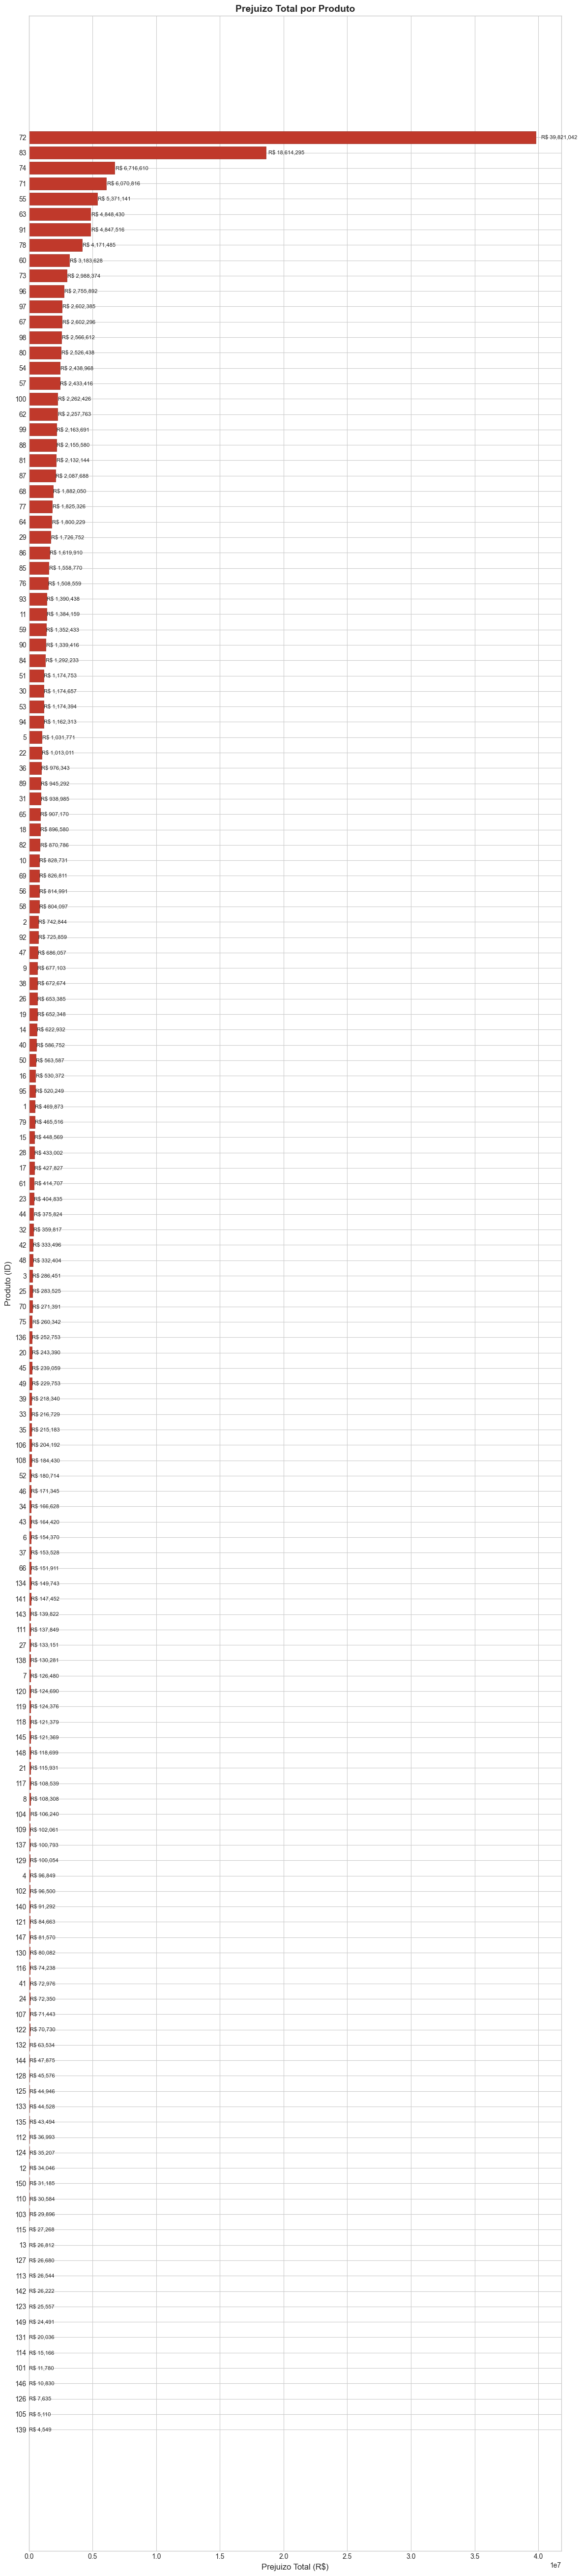

Grafico salvo em: ../outputs/graficos/prejuizo_por_produto.png


In [13]:
df_plot = df_com_prejuizo.sort_values('prejuizo_total', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(6, len(df_plot) * 0.35)))

bars = ax.barh(
    df_plot['product_id'].astype(str),
    df_plot['prejuizo_total'],
    color='#c0392b',
    edgecolor='#922b21',
    linewidth=0.5
)

ax.set_xlabel('Prejuizo Total (R$)', fontsize=12)
ax.set_ylabel('Produto (ID)', fontsize=12)
ax.set_title('Prejuizo Total por Produto', fontsize=14, fontweight='bold')

for bar in bars:
    width = bar.get_width()
    if width > 0:
        ax.text(
            width * 1.01,
            bar.get_y() + bar.get_height() / 2,
            f'R$ {width:,.0f}',
            ha='left',
            va='center',
            fontsize=8
        )

plt.tight_layout()
plt.savefig('../outputs/graficos/prejuizo_por_produto.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvo em: ../outputs/graficos/prejuizo_por_produto.png")

## 10. Respostas as Questoes de Validacao

In [14]:
produto_maior_prejuizo_abs = df_com_prejuizo.iloc[0]
produto_maior_percentual = df_com_prejuizo.sort_values('percentual_perda', ascending=False).iloc[0]

print("=" * 70)
print("RESPOSTAS - QUESTAO 4")
print("=" * 70)

print(f"\nQuestao 4.2 - Qual produto possui o maior prejuizo absoluto?")
print(f"Produto ID: {int(produto_maior_prejuizo_abs['product_id'])}")
print(f"Prejuizo Total: R$ {produto_maior_prejuizo_abs['prejuizo_total']:,.2f}")
print(f"Receita Total: R$ {produto_maior_prejuizo_abs['receita_total']:,.2f}")
print(f"Percentual de Perda: {produto_maior_prejuizo_abs['percentual_perda']:.2f}%")

print(f"\nProduto com maior percentual de perda:")
print(f"Produto ID: {int(produto_maior_percentual['product_id'])}")
print(f"Percentual de Perda: {produto_maior_percentual['percentual_perda']:.2f}%")
print(f"Prejuizo Total: R$ {produto_maior_percentual['prejuizo_total']:,.2f}")

mesmo_produto = (
    int(produto_maior_prejuizo_abs['product_id']) == int(produto_maior_percentual['product_id'])
)

resposta = "Sim" if mesmo_produto else "Nao"
print(f"\nO produto com maior prejuizo absoluto tambem possui o maior percentual de perda?")
print(f"Resposta: {resposta}")

RESPOSTAS - QUESTAO 4

Questao 4.2 - Qual produto possui o maior prejuizo absoluto?
Produto ID: 72
Prejuizo Total: R$ 39,821,041.68
Receita Total: R$ 63,057,815.65
Percentual de Perda: 63.15%

Produto com maior percentual de perda:
Produto ID: 72
Percentual de Perda: 63.15%
Prejuizo Total: R$ 39,821,041.68

O produto com maior prejuizo absoluto tambem possui o maior percentual de perda?
Resposta: Sim


## SQL de Referencia (Questao 4.1)

```sql
-- SQL Reference (Questao 4.1)
-- This SQL assumes tables: vendas, custos_importacao, cambio

WITH custos_aplicaveis AS (
    SELECT 
        v.id AS id_venda,
        v.id_product,
        v.qtd,
        v.total AS receita_brl,
        v.sale_date,
        c.usd_price,
        cb.taxa_cambio,
        (c.usd_price * cb.taxa_cambio * v.qtd) AS custo_total_brl,
        CASE 
            WHEN v.total < (c.usd_price * cb.taxa_cambio * v.qtd)
            THEN (c.usd_price * cb.taxa_cambio * v.qtd) - v.total
            ELSE 0
        END AS prejuizo
    FROM vendas v
    INNER JOIN custos_importacao c 
        ON v.id_product = c.product_id
    INNER JOIN cambio cb 
        ON v.sale_date = cb.data
    WHERE c.start_date = (
        SELECT MAX(c2.start_date) 
        FROM custos_importacao c2 
        WHERE c2.product_id = v.id_product 
        AND c2.start_date <= v.sale_date
    )
)
SELECT
    id_product,
    SUM(receita_brl) AS receita_total,
    SUM(prejuizo) AS prejuizo_total,
    ROUND(SUM(prejuizo) / NULLIF(SUM(receita_brl), 0) * 100, 2) AS percentual_perda
FROM custos_aplicaveis
GROUP BY id_product
ORDER BY prejuizo_total DESC;
```

## Interpretacao dos Resultados (Questao 4.3)

### Metodologia aplicada

1. **Cambio**: Utilizou-se a media da cotacao de venda PTAX do dia da transacao, obtida diretamente da API publica do Banco Central do Brasil.

2. **Prejuizo**: Definido como a diferenca positiva entre o custo total em BRL (custo unitario USD multiplicado pela taxa de cambio e quantidade) e a receita da venda. Somente vendas em que o custo total superou a receita foram classificadas como operacoes com prejuizo.

3. **Premissa para dias sem cotacao**: Para fins de semana e feriados, nos quais nao ha cotacao PTAX disponivel, utilizou-se a cotacao do ultimo dia util anterior (metodo forward fill). Esta abordagem e amplamente adotada no mercado financeiro e garante que todas as vendas possuam uma taxa de cambio associada.

4. **Associacao de custos**: Para cada venda, o custo aplicavel e determinado pela entrada historica mais recente com data de inicio anterior ou igual a data da venda (merge temporal retroativo). Isso reflete o custo vigente no momento da transacao.

### Consideracoes

- O percentual de perda permite identificar produtos que, embora possam nao ter o maior prejuizo absoluto, apresentam uma proporcao elevada de perda em relacao a sua receita.
- A analise nao considera impostos, frete ou outros custos operacionais, que poderiam ampliar o prejuizo real.
- Produtos com prejuizo elevado devem ser avaliados quanto a sua estrategia de precificacao e politica cambial.